# 09 — Synthetic Photometry

This notebook demonstrates how to compute synthetic magnitudes and fluxes from interpolated SEDs using the `photometry()` method.

**Key method:** `EvaluatedSED.photometry(*filters, system='AB')`

**Supported systems:** AB (default), Vega

Filter transmission curves must be installed first — see notebook 08.

In [1]:
from sed_tools.api import SED, Filters
import matplotlib.pyplot as plt
import numpy as np

## 1. Setup — Load a Catalog and Filters

Filters are identified by their filename stem only (e.g. `"G"` for `GAIA/GAIA/G.dat`). Ensure the relevant filter set is downloaded before calling `photometry()`.

In [2]:
try:
    sed = SED.local('Kurucz2003all')
    print("Loaded Kurucz2003all")
except Exception as e:
    print(f"Catalog not available: {e}")

# Download Gaia and Johnson filters if not already present:
Filters.fetch('GAIA', 'GAIA')
Filters.fetch('Generic', 'Johnson')

Loaded Kurucz2003all
[filters] Already have 4 filters at /home/njm/SED_Tools/data/filters/GAIA/GAIA
[filters] Already have 7 filters at /home/njm/SED_Tools/data/filters/Generic/Johnson


PosixPath('/home/njm/SED_Tools/data/filters/Generic/Johnson')

## 2. Computing Synthetic Magnitudes

Interpolate a spectrum, then call `.photometry()` with filter names. Returns a dict of `PhotometryResult` objects.

In [3]:
if 'sed' in locals():
    spectrum = sed(teff=5777, logg=4.44, metallicity=0.0)

    phot = spectrum.photometry('Grp', 'BP', 'RP', system='AB')

    for band, result in phot.items():
        print(f"  {band:4s}: {result.magnitude:.4f} AB mag")

  Grp : -35.5981 AB mag
  Gbp : -36.5049 AB mag


### Vega System

Pass `system='Vega'` and, optionally, a Vega reference spectrum path if the filter file does not encode a zero-point.

In [4]:
from pathlib import Path

if 'sed' in locals():
    V_path = Path("/home/njm/SED_Tools/data/filters/Generic/Johnson/V.dat")
    B_path = Path("/home/njm/SED_Tools/data/filters/Generic/Johnson/B.dat")
    vega_path = Path("/home/njm/SED_Tools/data/stellar_models/vega_sed.txt")

    phot_vega = spectrum.photometry(
        V_path,
        B_path,
        system="Vega",
        vega_spectrum=vega_path
    )

    for band, result in phot_vega.items():
        print(f"  {band}: {result.magnitude:.4f} Vega mag")

  V: -31.2880 Vega mag
  B: -31.5601 Vega mag


## 3. Color–Temperature Relation

Sweep Teff at fixed logg and metallicity to build a synthetic color–temperature diagram.

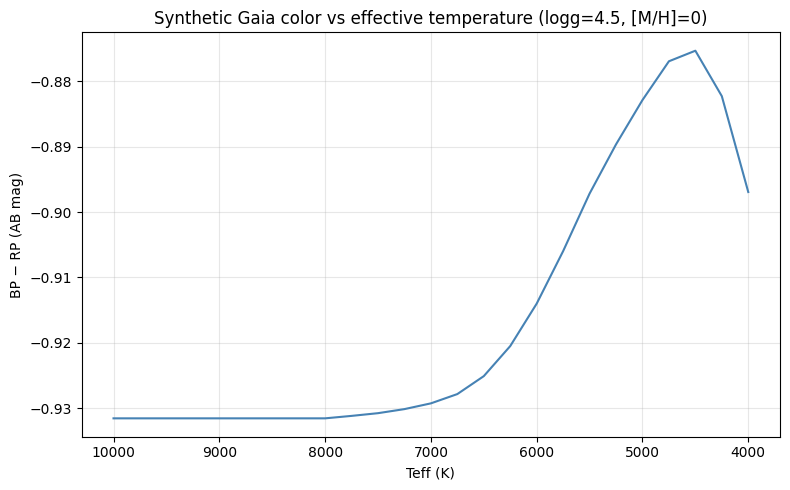

In [5]:
if 'sed' in locals():
    teffs = np.arange(4000, 10001, 250)
    bp_rp = []

    for t in teffs:
        spec = sed(teff=float(t), logg=4.5, metallicity=0.0)
        phot = spec.photometry('Gbp', 'Grp', system='AB')
        bp_rp.append(phot['Gbp'].magnitude - phot['Grp'].magnitude)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(teffs, bp_rp, lw=1.5, color='steelblue')
    ax.invert_xaxis()
    ax.set_xlabel('Teff (K)')
    ax.set_ylabel('BP − RP (AB mag)')
    ax.set_title('Synthetic Gaia color vs effective temperature (logg=4.5, [M/H]=0)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. CMD from a Catalog Subset

Compute photometry for every spectrum in a catalog subset to produce a synthetic color–magnitude diagram.

Computing photometry for 510 spectra...


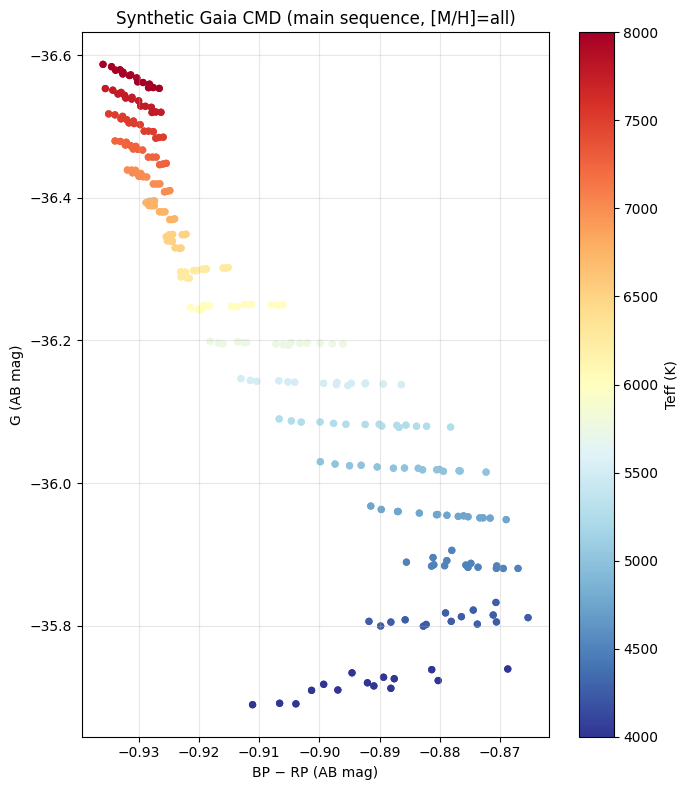

In [8]:
from pathlib import Path

if 'sed' in locals():
    subset = sed.cat.filter(teff_min=4000, teff_max=10000, logg_min=4.0)
    print(f"Computing photometry for {len(subset)} spectra...")

    gaia_dir = Path.home() / "SED_Tools" / "data" / "filters" / "GAIA" / "GAIA"
    G_path   = gaia_dir / "G.dat"
    Gbp_path = gaia_dir / "Gbp.dat"
    Grp_path = gaia_dir / "Grp.dat"

    bp_rp_vals, g_vals, teff_vals = [], [], []

    for row in subset:
        eval_spec = sed(
            teff=float(row.teff),
            logg=float(row.logg),
            metallicity=float(row.metallicity),
        )

        phot = eval_spec.photometry(G_path, Gbp_path, Grp_path, system="AB")

        bp_rp_vals.append(phot["Gbp"].magnitude - phot["Grp"].magnitude)
        g_vals.append(phot["G"].magnitude)
        teff_vals.append(float(row.teff))

    fig, ax = plt.subplots(figsize=(7, 8))
    sc = ax.scatter(bp_rp_vals, g_vals, c=teff_vals, cmap="RdYlBu_r", s=18)
    plt.colorbar(sc, ax=ax, label="Teff (K)")
    ax.invert_yaxis()
    ax.set_xlabel("BP − RP (AB mag)")
    ax.set_ylabel("G (AB mag)")
    ax.set_title("Synthetic Gaia CMD (main sequence, [M/H]=all)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()